In [55]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [56]:
train = pd.read_csv("dataset/Titanic/train.csv")
test = pd.read_csv("dataset/Titanic/test.csv")

In [57]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [59]:
train.dropna(inplace=True)

In [60]:
train.drop(['PassengerId','Pclass','Name','SibSp','Parch','Ticket','Fare','Cabin','Embarked'],axis=1,inplace=True)
train.head()

,Survived,Sex,Age
1,1,female,38.0
3,1,female,35.0
6,0,male,54.0
10,1,female,4.0
11,1,female,58.0


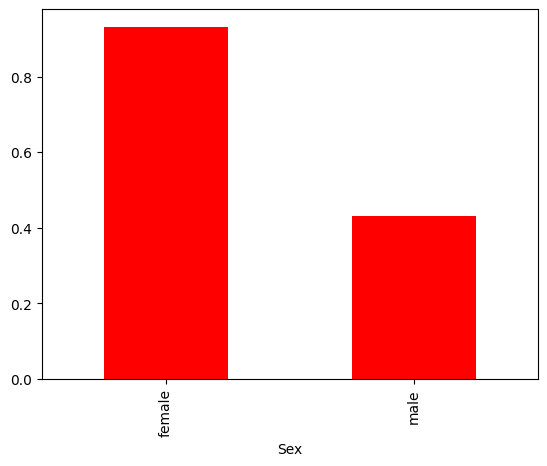

In [61]:
df = train.groupby('Sex').mean()['Survived']
df.plot(kind='bar',color='r')
plt.show()

In [62]:
for i in train.index:
    if train.loc[i,'Sex']=='male':
        train.loc[i,'Sex']=1
    else:
        train.loc[i,'Sex']=0
train.head()

,Survived,Sex,Age
1,1,0,38.0
3,1,0,35.0
6,0,1,54.0
10,1,0,4.0
11,1,0,58.0


In [63]:
target= np.ravel(train.Survived)
target

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1], dtype=int64)

In [64]:
train.head()

,Survived,Sex,Age
1,1,0,38.0
3,1,0,35.0
6,0,1,54.0
10,1,0,4.0
11,1,0,58.0


In [65]:
train.drop(['Survived'],inplace=True,axis=1)
train = train.astype(float)
train.head()

,Sex,Age
1,0.0,38.0
3,0.0,35.0
6,1.0,54.0
10,0.0,4.0
11,0.0,58.0


In [66]:
model =Sequential()
model.add(Dense(16,input_shape=(2,),activation='relu',name='input'))
model.add(Dense(8,activation='relu',name='hidden'))
model.add(Dense(1,activation='sigmoid',name='output'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Dense)               (None, 16)                48        
                                                                 
 hidden (Dense)              (None, 8)                 136       
                                                                 
 output (Dense)              (None, 1)                 9         
                                                                 
Total params: 193
Trainable params: 193
Non-trainable params: 0
_________________________________________________________________


In [70]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [72]:
history = model.fit(train,target, epochs=100, batch_size=5)

Epoch 1/100
37/37 [==============================] - 3s 4ms/step - loss: 0.6994 - accuracy: 0.6230
Epoch 2/100
37/37 [==============================] - 0s 4ms/step - loss: 0.6607 - accuracy: 0.6721
Epoch 3/100
37/37 [==============================] - 0s 4ms/step - loss: 0.6548 - accuracy: 0.6667
Epoch 4/100
37/37 [==============================] - 0s 3ms/step - loss: 0.6476 - accuracy: 0.6721
Epoch 5/100
37/37 [==============================] - 0s 3ms/step - loss: 0.6453 - accuracy: 0.6721
Epoch 6/100
37/37 [==============================] - 0s 3ms/step - loss: 0.6295 - accuracy: 0.6776
Epoch 7/100
37/37 [==============================] - 0s 3ms/step - loss: 0.6346 - accuracy: 0.6831
Epoch 8/100
37/37 [==============================] - 0s 5ms/step - loss: 0.6244 - accuracy: 0.7049
Epoch 9/100
37/37 [==============================] - 0s 4ms/step - loss: 0.6272 - accuracy: 0.7213
Epoch 10/100
37/37 [==============================] - 0s 3ms/step - loss: 0.6013 - accuracy: 0.6667
Epoch 11/